In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_data.csv")
df

,Unnamed: 0,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type
0,0,387,6.094781,7.423652,No,No,Yes,Roots and tubers
1,2,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco..."
2,3,362,6.096048,7.417137,No,No,No,Roots and tubers
3,5,178,6.426840,7.346881,No,No,No,Fodder plants
4,7,128,5.609925,6.615464,No,No,No,Oilcrops
...,...,...,...,...,...,...,...,...
7751,13855,1180,-5.282243,31.366502,No,No,Yes,Fodder plants
7752,13856,1190,-5.280960,31.366483,No,No,Yes,Fruits
7753,13857,1188,-5.281934,31.367701,No,No,No,Fodder plants
7754,13864,879,-3.795245,33.273638,No,No,Yes,Fodder plants


In [5]:
df.drop(df.columns[0], axis = 1, inplace = True)
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco..."
2,362,6.096048,7.417137,No,No,No,Roots and tubers
3,178,6.426840,7.346881,No,No,No,Fodder plants
4,128,5.609925,6.615464,No,No,No,Oilcrops
...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants


In [8]:
from sklearn.cluster import KMeans

In [7]:
coords = df[['longitude', 'latitude']]
wcss = []
k_range = range(1, 11)

In [9]:
for k in k_range:
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42, n_init = 10)
    kmeans.fit(coords)
    wcss.append(kmeans.inertia_)

In [10]:
wcss

[3878662.4907204346,
 1148267.7542247004,
 816699.0336768834,
 573851.707575937,
 452481.63026972534,
 350302.329654391,
 293388.05750204204,
 230768.37656869862,
 183981.10615226033,
 158348.10847175797]

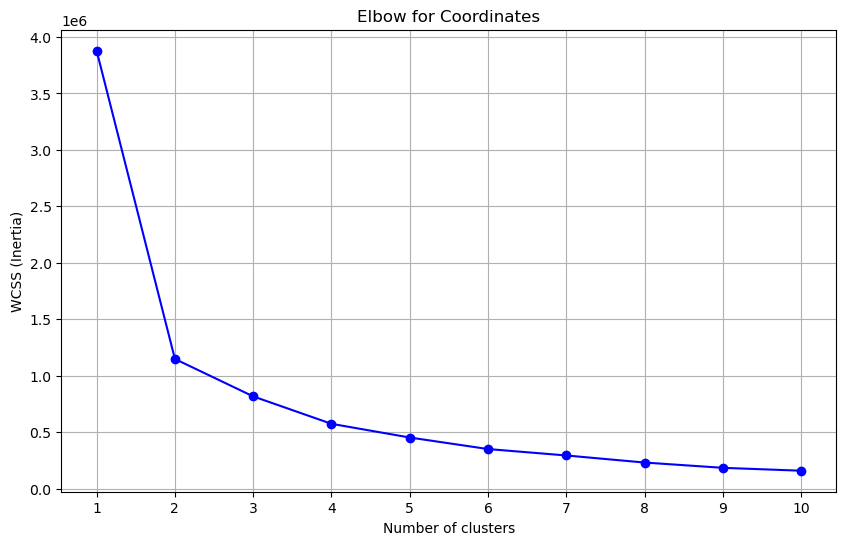

In [11]:
plt.figure(figsize = (10, 6))
plt.plot(k_range, wcss, marker = 'o', linestyle = '-', color = 'b')
plt.title('Elbow for Coordinates')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)') #Measure of how 'close' points are
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [52]:
#Applying DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 2.5, min_samples = 15)
cluster_labels = dbscan.fit_predict(coords)

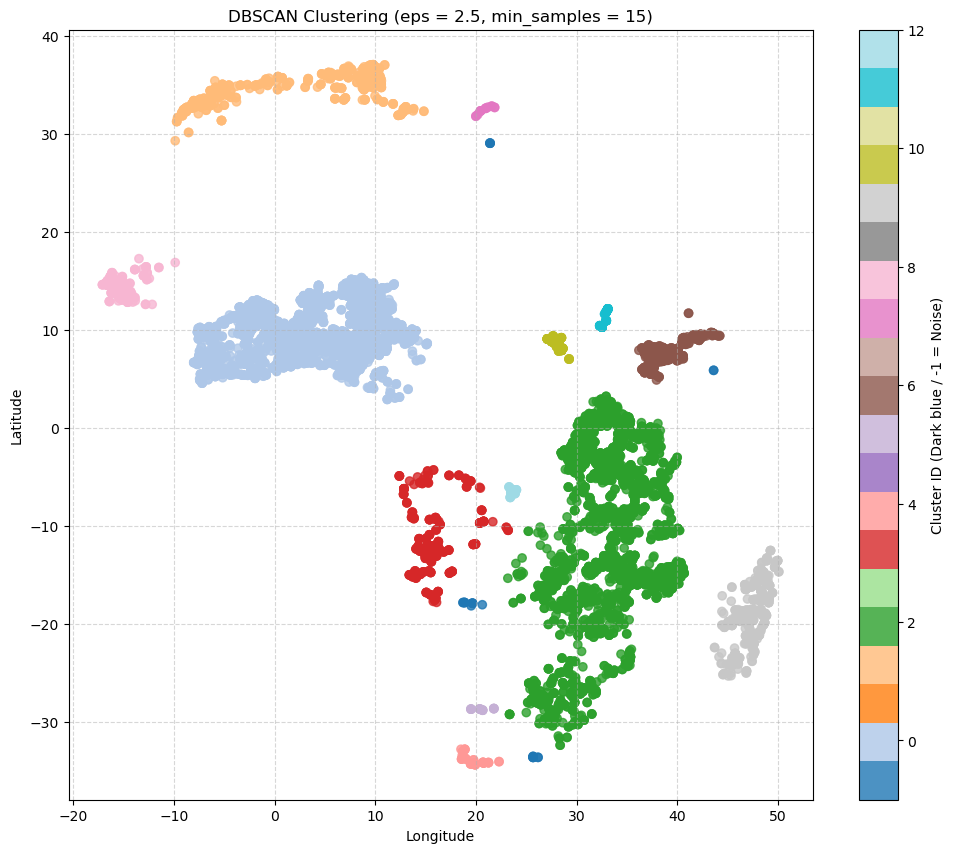

In [53]:
plt.figure(figsize = (12, 10))
scatter = plt.scatter(df['longitude'], df['latitude'], c = cluster_labels, cmap = 'tab20', alpha = 0.8)
plt.title(f'DBSCAN Clustering (eps = {dbscan.eps}, min_samples = {dbscan.min_samples})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(scatter, label = 'Cluster ID (Dark blue / -1 = Noise)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

In [29]:
print(cluster_labels)
len(cluster_labels)

[0 0 0 ... 1 1 5]


7756

In [30]:
distinct_clusters = np.unique(cluster_labels)
print(distinct_clusters)

[-1  0  1  2  3  4  5  6  7  8  9 10]
